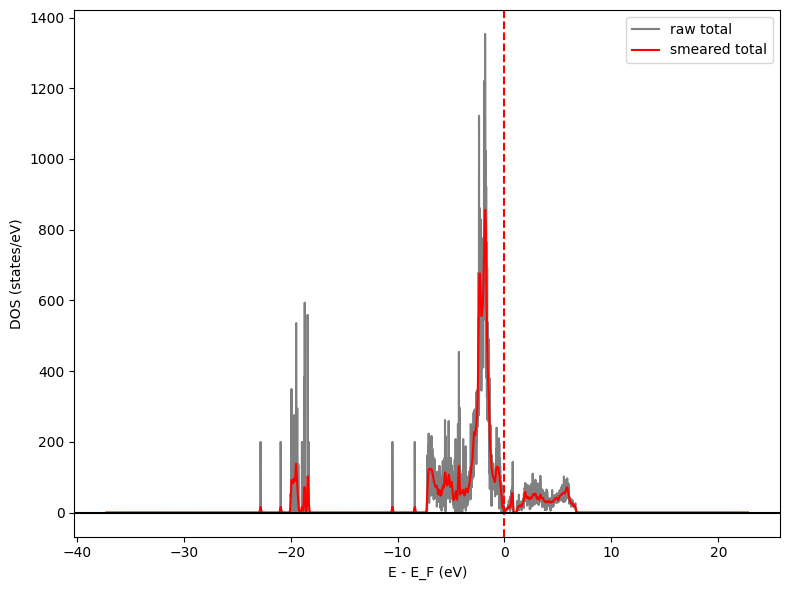

Selected: C:\Users\user\Desktop\vasprun.xml
E_F = -2.773259 eV, sigma = 0.050 eV
CSV saved: C:\Users\user\Desktop\dos_smeared_sigma_0.05.csv


In [15]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.electronic_structure.core import Spin

# --- GUI file picker (Jupyter) ---
def pick_file(title="Select vasprun.xml", filetypes=(("VASP vasprun.xml", "vasprun.xml"),
                                                    ("XML files", "*.xml"),
                                                    ("All files", "*.*"))):
    """
    Returns Path to selected file or raises RuntimeError if user cancels.
    """
    try:
        from tkinter import Tk, filedialog
        root = Tk()
        root.withdraw()
        root.attributes("-topmost", True)
        path = filedialog.askopenfilename(title=title, filetypes=filetypes)
        root.destroy()
    except Exception as e:
        raise RuntimeError(
            f"Tkinter file dialog failed. If you're on a headless/remote notebook, "
            f"set the path manually. Original error: {e}"
        )

    if not path:
        raise RuntimeError("No file selected (cancelled).")
    return Path(path)

# --- Load DOS from vasprun.xml ---
def load_total_dos(vasprun_path: Path):
    vr = Vasprun(
        str(vasprun_path),
        parse_dos=True,
        parse_eigen=False,
        exception_on_bad_xml=False,
    )
    dos = vr.complete_dos  # CompleteDos
    energies = np.array(dos.energies, dtype=float)
    efermi = float(dos.efermi)
    raw = {k: np.array(v, dtype=float) for k, v in dos.densities.items()}  # dict[Spin] -> DOS
    return energies, efermi, raw, dos

# --- Gaussian smearing using pymatgen built-in method ---
def gaussian_smear(dos_obj, sigma_ev: float):
    if not hasattr(dos_obj, "get_smeared_densities"):
        raise AttributeError("DOS object does not support get_smeared_densities(sigma).")
    smeared = dos_obj.get_smeared_densities(sigma_ev)
    return {k: np.array(v, dtype=float) for k, v in smeared.items()}

# --- Save CSV (E referenced to Ef) ---
def save_csv(out_csv: Path, energies: np.ndarray, efermi: float, smeared: dict):
    e_rel = energies - efermi

    up = smeared.get(Spin.up, np.zeros_like(e_rel))
    down = smeared.get(Spin.down, np.zeros_like(e_rel))
    total = up + down

    header = ["E_minus_Ef_eV", "DOS_smeared_total"]
    
    data = np.column_stack([e_rel, total])
    np.savetxt(out_csv, data, delimiter=",", header=",".join(header), comments="")

# --- Plot ---
def plot_dos(energies: np.ndarray, efermi: float, raw: dict, smeared: dict):
    e_rel = energies - efermi
    raw_total = raw.get(Spin.up, np.zeros_like(e_rel)) + raw.get(Spin.down, np.zeros_like(e_rel))
    smeared_total = smeared.get(Spin.up, np.zeros_like(e_rel)) + smeared.get(Spin.down, np.zeros_like(e_rel))
    plt.figure(figsize=(8, 6))
    plt.plot(e_rel, raw_total, linestyle="-", color="gray", label="raw total")
    plt.plot(e_rel, smeared_total, linestyle="-", color="red", label="smeared total")

    plt.axvline(0.0, linestyle="--", color="red")  # E - Ef = 0
    plt.axhline(0.0, linestyle="-", color="black")
    plt.xlabel("E - E_F (eV)")
    plt.ylabel("DOS (states/eV)")
    plt.legend()
    plt.tight_layout()
    plt.show()

# =========================
# Jupyter execution section
# =========================
sigma = 0.05  # eV: adjust as needed

vasprun_path = pick_file("Select vasprun.xml")
energies, efermi, raw, dos_obj = load_total_dos(vasprun_path)
smeared = gaussian_smear(dos_obj, sigma_ev=sigma)

# Plot
plot_dos(energies, efermi, raw, smeared)

# Save CSV next to vasprun.xml
out_csv = vasprun_path.with_name(f"dos_smeared_sigma_{sigma}.csv")
save_csv(out_csv, energies, efermi, smeared)

print(f"Selected: {vasprun_path}")
print(f"E_F = {efermi:.6f} eV, sigma = {sigma:.3f} eV")
print(f"CSV saved: {out_csv}")